# FedFlower Phase 1 — Centralized CNN Baseline

> **Before running:** Go to `Runtime → Change Runtime Type → T4 GPU → Save`

## Cell 1 — Install Libraries
Run this every time you open a new Colab session.

In [ ]:
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118 -q
!pip install matplotlib numpy pillow scikit-learn grad-cam -q
!pip install tensorflow onnx onnxruntime -q
print("✅ All libraries installed")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 83.4 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.1/19.1 MB 90.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.7/18.7 MB 97.8 MB/s eta 0:00:00
✅ All libraries installed


## Cell 2 — Verify GPU

In [ ]:
import torch
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("⚠️  No GPU! Go to Runtime → Change Runtime Type → T4 GPU")

CUDA available: True
GPU: Tesla T4


## Cell 3 — Download Oxford 102 Flowers Dataset (~330 MB, takes 2-3 min first time)

In [ ]:
import torchvision.datasets as datasets
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, ConcatDataset

train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.7, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.1),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

test_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

print("Downloading Oxford 102 Flowers...")
# both splits loaded WITH train_transform since both are now training data
train_split = datasets.Flowers102(root='./data', split='train', download=True, transform=train_transform)
val_split   = datasets.Flowers102(root='./data', split='val',   download=True, transform=train_transform)
test_data   = datasets.Flowers102(root='./data', split='test',  download=True, transform=test_transform)

full_train_data = ConcatDataset([train_split, val_split])

train_loader = DataLoader(full_train_data, batch_size=32, shuffle=True,  num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_data,        batch_size=32, shuffle=False, num_workers=2, pin_memory=True)

print(f"✅ Full train pool: {len(full_train_data)} | Test: {len(test_data)}")

100%|██████████| 345M/345M [00:13<00:00, 25.4MB/s]
100%|██████████| 502/502 [00:00<00:00, 906kB/s]
100%|██████████| 15.0k/15.0k [00:00<00:00, 39.2MB/s]


✅ Full train pool: 2040 | Test: 6149


## Cell 4 — Visualize Sample Images

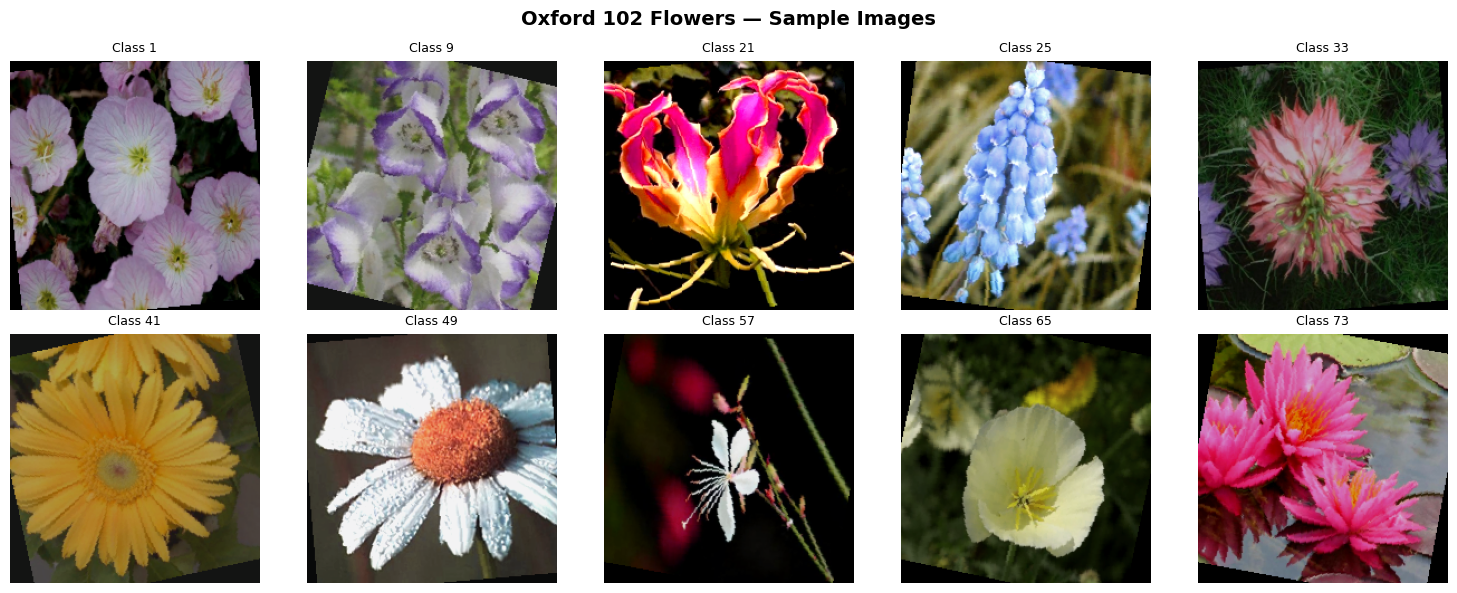

✅ Saved sample_flowers.png


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
fig.suptitle("Oxford 102 Flowers — Sample Images", fontsize=14, fontweight='bold')
for i, ax in enumerate(axes.flat):
    img, label = full_train_data[i * 80]
    img = img.numpy().transpose(1, 2, 0)
    img = img * [0.229, 0.224, 0.225] + [0.485, 0.456, 0.406]
    img = np.clip(img, 0, 1)
    ax.imshow(img)
    ax.set_title(f'Class {label + 1}', fontsize=9)
    ax.axis('off')
plt.tight_layout()
plt.savefig('sample_flowers.png', dpi=150)
plt.show()
print("✅ Saved sample_flowers.png")

## Cell 5 — Build the CNN Model (ResNet50 + Transfer Learning)

**Why ResNet50?** Pre-trained on 1.2M ImageNet images — already knows edges, textures, shapes. We freeze early layers and only train the final flower-specific head. This is *transfer learning*.

In [ ]:
import torch
import torch.nn as nn
import torchvision.models as models

class FlowerCNN(nn.Module):
    def __init__(self, num_classes=102):
        super(FlowerCNN, self).__init__()
        self.backbone = models.resnet50(weights='IMAGENET1K_V2')
        # Freeze early layers — they already detect edges/textures
        for name, param in self.backbone.named_parameters():
            if 'layer4' not in name and 'fc' not in name:
                param.requires_grad = False
        # Replace final classifier for 102 flower classes
        in_features = self.backbone.fc.in_features
        self.backbone.fc = nn.Sequential(
            nn.Linear(in_features, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.4),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        return self.backbone(x)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model  = FlowerCNN(num_classes=102).to(device)
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f"✅ Model on: {device}")
print(f"   Trainable: {trainable:,} / {total:,} params ({100*trainable/total:.1f}%)")

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 136MB/s]


✅ Model on: cuda
   Trainable: 16,067,174 / 24,610,470 params (65.3%)


## Cell 6 — Training Setup

In [ ]:
import torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingLR

criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-4, weight_decay=1e-4)
scheduler = CosineAnnealingLR(optimizer, T_max=30)

def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item()
        _, preds = outputs.max(1)
        correct += preds.eq(labels).sum().item()
        total   += labels.size(0)
    return total_loss / len(loader), 100.0 * correct / total

def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            total_loss += loss.item()
            _, preds = outputs.max(1)
            correct += preds.eq(labels).sum().item()
            total   += labels.size(0)
    return total_loss / len(loader), 100.0 * correct / total

print("✅ Training functions ready")

✅ Training functions ready


## Cell 7 — Train for 30 Epochs (~25 minutes on T4)

Expected: val accuracy reaches **85–92%** by epoch 30. Best model auto-saved as `best_model.pth`.

In [ ]:
EPOCHS = 30
history = {'train_loss': [], 'train_acc': []}

print(f"{'Epoch':>6} {'Loss':>10} {'Train':>9}")
print("─" * 30)

for epoch in range(EPOCHS):
    train_loss, train_acc = train_epoch(model, train_loader, optimizer, criterion, device)
    scheduler.step()

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)

    print(f"{epoch+1:>6} {train_loss:>10.4f} {train_acc:>8.2f}%")

# save unconditionally after the LAST epoch — no "is_best" check, no val comparison
torch.save(model.state_dict(), 'final_model_fulltrain.pth')
print(f"\n✅ Done! Final-epoch weights saved as final_model_fulltrain.pth")

 Epoch       Loss     Train
──────────────────────────────
     1     4.3733     9.71%
     2     3.3739    47.40%
     3     2.5902    71.91%
     4     2.0237    83.53%
     5     1.5866    90.88%
     6     1.3317    93.43%
     7     1.1255    96.37%
     8     1.0321    97.55%
     9     0.9764    98.53%
    10     0.9189    99.31%
    11     0.9081    99.26%
    12     0.8896    99.36%
    13     0.8873    99.51%
    14     0.8764    99.66%
    15     0.8772    99.71%
    16     0.8742    99.61%
    17     0.8642    99.71%
    18     0.8599    99.71%
    19     0.8573    99.80%
    20     0.8553    99.75%
    21     0.8499    99.80%
    22     0.8485    99.75%
    23     0.8436   100.00%
    24     0.8436    99.95%
    25     0.8394   100.00%
    26     0.8430   100.00%
    27     0.8432   100.00%
    28     0.8399    99.95%
    29     0.8405    99.95%
    30     0.8420   100.00%

✅ Done! Final-epoch weights saved as final_model_fulltrain.pth


## Cell 8 — Plot Training History

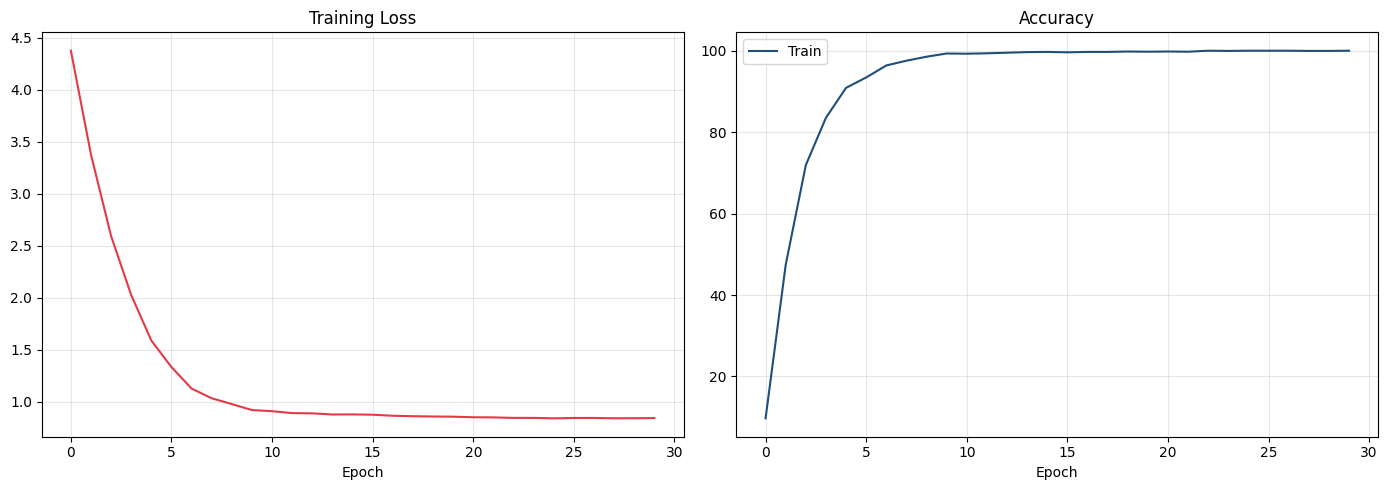

In [ ]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(history['train_loss'], color='#E63946')
ax1.set_title('Training Loss'); ax1.set_xlabel('Epoch'); ax1.grid(True, alpha=0.3)
ax2.plot(history['train_acc'], label='Train', color='#1F4E79')
ax2.set_title('Accuracy'); ax2.set_xlabel('Epoch'); ax2.legend(); ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('training_history.png', dpi=150)
plt.show()

## Cell 9 — Final Test Set Evaluation

**Write down the test accuracy** — you will compare it against federated learning in Notebook 2.

In [ ]:
from sklearn.metrics import f1_score
import numpy as np, json

model.load_state_dict(torch.load('final_model_fulltrain.pth'))
model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for imgs, labels in test_loader:
        imgs = imgs.to(device)
        _, preds = model(imgs).max(1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

test_acc = 100.0 * np.sum(np.array(all_preds) == np.array(all_labels)) / len(all_labels)
f1       = f1_score(all_labels, all_preds, average='macro')

print("=" * 50)
print("CENTRALIZED CNN (FULL 2040-IMAGE TRAIN) — FINAL TEST RESULTS")
print("=" * 50)
print(f"Top-1 Accuracy : {test_acc:.2f}%")
print(f"Macro F1-Score : {f1:.4f}")
print("=" * 50)

with open('centralized_full_results.json', 'w') as f:
    json.dump({"centralized_full_test_acc": test_acc, "centralized_full_f1": f1}, f, indent=2)

CENTRALIZED CNN (FULL 2040-IMAGE TRAIN) — FINAL TEST RESULTS
Top-1 Accuracy : 94.06%
Macro F1-Score : 0.9382


In [ ]:
from google.colab import files
files.download('final_model_fulltrain.pth')
files.download('centralized_full_results.json')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>